# Проект

## Установка библиотек

In [ ]:
!pip install pgmpy
!pip install catboost

## Импорт библиотек и общие настройки

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from scipy import stats
from IPython.display import display

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold, KFold)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              RandomForestRegressor, GradientBoostingRegressor)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, make_scorer,
                             mean_squared_error, mean_absolute_percentage_error)

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator, HillClimbSearch, BIC
from pgmpy.inference import VariableElimination
from catboost import CatBoostClassifier, CatBoostRegressor

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 250)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # для классификации
kf = KFold(n_splits=5, shuffle=True, random_state=42)             # для регрессии
rmse = lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))

## Раздел 2. Генерация и предварительная обработка данных
### Задание 2.2. Симуляция данных, корреляционная матрица и описательные статистики
Процесс генерации (задание 2.1) описан в отчёте. Здесь данные симулируются, приводятся корреляционная матрица и описательные статистики, выборка делится на train/test (задание 2.3).

In [ ]:
np.random.seed(42)
n = 2000

# Экзогенные переменные
Z = np.random.binomial(1, 0.5, n)                 # PilotVoucher (инструмент)
U = np.random.normal(0, 1, n)                     # EntrepreneurialAbility (ненаблюдаемая)
BusinessAge = np.random.gamma(shape=2, scale=3, size=n)
EmployeeCount = np.random.poisson(lam=5, size=n)
OnlineSuitable = np.random.binomial(1, 0.6, n)

# Переменная воздействия D (MarketplaceAdoption);
# alpha_0 = -2.4 подобран так, чтобы доля D=1 составляла ~45%.
alpha_0, alpha_1, alpha_2, alpha_3 = -2.4, 1.0, 0.8, 0.3
alpha_4, alpha_5, alpha_6, alpha_7 = -0.02, 0.1, 0.5, 0.5

# Единый шок epsilon_D используется и для наблюдаемого D, и для потенциальных
# исходов D(0), D(1) => наблюдаемое D в точности равно D(Z).
epsilon_D = np.random.normal(0, 1, n)

In [ ]:
def D_star(z):
    return (alpha_0 + alpha_1 * z + alpha_2 * U +
            alpha_3 * BusinessAge + alpha_4 * BusinessAge**2 +
            alpha_5 * EmployeeCount + alpha_6 * OnlineSuitable +
            alpha_7 * z * OnlineSuitable + epsilon_D)

D  = (D_star(Z) > 0).astype(int)
D1 = (D_star(1) > 0).astype(int)
D0 = (D_star(0) > 0).astype(int)
complier = (D1 > D0).astype(int)      # подчиняющиеся (compliers)

In [ ]:
#Зависимая переменная Y (Revenue)
beta_0, beta_1, beta_2, beta_3, beta_4 = 4.5, 0.05, 0.08, 0.2, 0.4
gamma_0, gamma_1, gamma_2, sigma_Y = 0.3, 0.2, 0.2, 0.4

tau = gamma_0 + gamma_1 * OnlineSuitable + gamma_2 * U      # гетерогенный эффект
epsilon_Y = np.random.normal(0, sigma_Y, n)
ln_Y0 = (beta_0 + beta_1 * BusinessAge + beta_2 * EmployeeCount +
         beta_3 * OnlineSuitable + beta_4 * U + epsilon_Y)
Y0, Y1 = np.exp(ln_Y0), np.exp(ln_Y0 + tau)
Y = D * Y1 + (1 - D) * Y0
observed_df = pd.DataFrame({'Revenue': Y, 'MarketplaceAdoption': D, 'PilotVoucher': Z,
                            'BusinessAge': BusinessAge, 'EmployeeCount': EmployeeCount,
                            'OnlineSuitable': OnlineSuitable})
full_df = observed_df.copy()
full_df['EntrepreneurialAbility'] = U
full_df['D1'], full_df['D0'], full_df['Complier'] = D1, D0, complier
full_df['Y1'], full_df['Y0'], full_df['tau'] = Y1, Y0, tau

In [ ]:
train_df, test_df = train_test_split(observed_df, test_size=0.25, random_state=42)
print(f'Train: {train_df.shape[0]} obs, Test: {test_df.shape[0]} obs')

Train: 1500 obs, Test: 500 obs


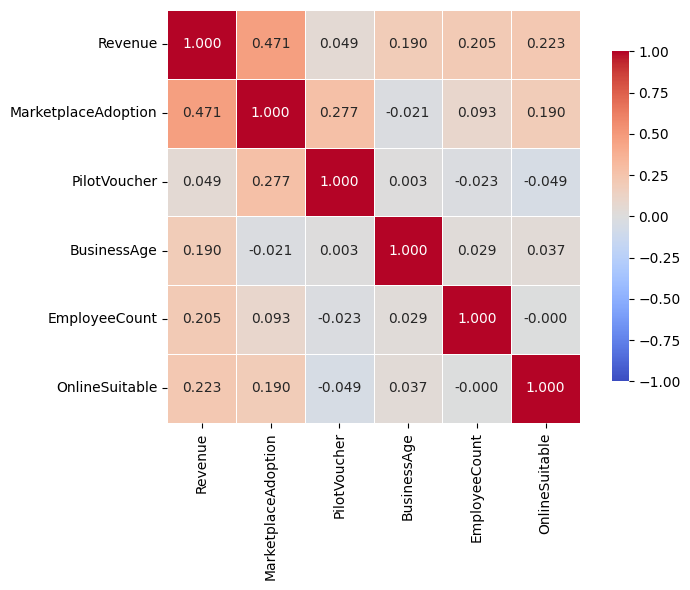

In [ ]:
#Корреляционная матрица
obs_vars = ['Revenue', 'MarketplaceAdoption', 'PilotVoucher',
            'BusinessAge', 'EmployeeCount', 'OnlineSuitable']
corr = observed_df[obs_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.tight_layout(); plt.savefig('corr_matrix.png'); plt.show()

In [ ]:
desc_cont = (observed_df[['Revenue', 'BusinessAge', 'EmployeeCount']].describe()
             .loc[['mean', 'std', '50%', 'min', 'max']].rename(index={'50%': 'median'}))
print('Описательные статистики непрерывных переменных\n')
print(desc_cont.round(2))

Описательные статистики непрерывных переменных

        Revenue  BusinessAge  EmployeeCount
mean     369.32         5.98           5.07
std      385.61         4.23           2.33
median   243.88         4.97           5.00
min       26.76         0.09           0.00
max     5278.87        34.90          15.00


In [ ]:
bin_vars = ['MarketplaceAdoption', 'PilotVoucher', 'OnlineSuitable']
bin_stats = pd.DataFrame({'Доля единиц': [observed_df[c].mean() for c in bin_vars],
                          'Количество единиц': [observed_df[c].sum() for c in bin_vars]}, index=bin_vars)
print('Описательные статистики бинарных переменных\n')
print(bin_stats.round(3))

Описательные статистики бинарных переменных

                     Доля единиц  Количество единиц
MarketplaceAdoption        0.448                895
PilotVoucher               0.506               1013
OnlineSuitable             0.567               1134


In [ ]:
print('Корреляционная матрица\n')
print(corr.round(3))

Корреляционная матрица

                     Revenue  MarketplaceAdoption  PilotVoucher  BusinessAge  EmployeeCount  OnlineSuitable
Revenue                1.000                0.471         0.049        0.190          0.205           0.223
MarketplaceAdoption    0.471                1.000         0.277       -0.021          0.093           0.190
PilotVoucher           0.049                0.277         1.000        0.003         -0.023          -0.049
BusinessAge            0.190               -0.021         0.003        1.000          0.029           0.037
EmployeeCount          0.205                0.093        -0.023        0.029          1.000          -0.000
OnlineSuitable         0.223                0.190        -0.049        0.037         -0.000           1.000


## Раздел 3. Классификация
Признаки (задание 3.1): PilotVoucher, BusinessAge, EmployeeCount, OnlineSuitable; целевая — MarketplaceAdoption. Ненаблюдаемая U и выручка Revenue в признаки не включаются.

### Задание 3.2. Базовое качество, тюнинг по кросс-валидации, переобучение


In [ ]:
FEATURES_CLF = ['PilotVoucher', 'BusinessAge', 'EmployeeCount', 'OnlineSuitable']
X_train, y_train = train_df[FEATURES_CLF], train_df['MarketplaceAdoption']
X_test,  y_test  = test_df[FEATURES_CLF],  test_df['MarketplaceAdoption']

In [ ]:
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'Базовая (тривиальная) точность на тесте: {baseline_acc:.3f}\n')

Базовая (тривиальная) точность на тесте: 0.558



In [ ]:
models_init = {
    'Логистическая регрессия': Pipeline([('sc', StandardScaler()),
                                          ('clf', LogisticRegression(C=1.0, max_iter=1000))]),
    'kNN':                     Pipeline([('sc', StandardScaler()),
                                          ('clf', KNeighborsClassifier(n_neighbors=5))]),
    'Случайный лес':           RandomForestClassifier(n_estimators=100, max_depth=None,
                                                      random_state=42, n_jobs=-1),
    'Градиентный бустинг':     GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                          max_depth=3, random_state=42),
}
init_params = {'Логистическая регрессия': 'C=1.0', 'kNN': 'k=5, uniform',
               'Случайный лес': 'n=100, depth=None, leaf=1', 'Градиентный бустинг': 'n=100, lr=0.1, depth=3'}
grids = {
    'Логистическая регрессия': {'clf__C': [0.01, 0.1, 1, 10]},
    'kNN':                     {'clf__n_neighbors': [5, 11, 21, 31], 'clf__weights': ['uniform', 'distance']},
    'Случайный лес':           {'n_estimators': [200, 400], 'max_depth': [3, 5, 8, None], 'min_samples_leaf': [1, 5, 10]},
    'Градиентный бустинг':     {'n_estimators': [100, 300], 'learning_rate': [0.03, 0.1], 'max_depth': [2, 3]},
}

rows_clf, tuned_models = [], {}
for name, mdl in models_init.items():
    mdl.fit(X_train, y_train)
    acc_tr0 = accuracy_score(y_train, mdl.predict(X_train))
    acc_te0 = accuracy_score(y_test,  mdl.predict(X_test))
    acc_cv0 = cross_val_score(mdl, X_train, y_train, cv=cv, scoring='accuracy').mean()

    gs = GridSearchCV(models_init[name], grids[name], cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    acc_tr1 = accuracy_score(y_train, gs.best_estimator_.predict(X_train))
    acc_te1 = accuracy_score(y_test,  gs.best_estimator_.predict(X_test))

    rows_clf.append({'Метод': name, 'Исходные гиперпараметры': init_params[name],
                     'Подобранные гиперпараметры': str(gs.best_params_),
                     'Train (исх.)': round(acc_tr0, 3), 'CV (исх.)': round(acc_cv0, 3),
                     'Test (исх.)': round(acc_te0, 3),
                     'Train (тюн.)': round(acc_tr1, 3), 'CV (тюн.)': round(gs.best_score_, 3),
                     'Test (тюн.)': round(acc_te1, 3)})

print('Точность классификаторов до и после тюнинга гиперпараметров\n')
print(pd.DataFrame(rows_clf).to_string(index=False))

Точность классификаторов до и после тюнинга гиперпараметров

                  Метод   Исходные гиперпараметры                                   Подобранные гиперпараметры  Train (исх.)  CV (исх.)  Test (исх.)  Train (тюн.)  CV (тюн.)  Test (тюн.)
Логистическая регрессия                     C=1.0                                             {'clf__C': 0.01}         0.673      0.665        0.640         0.671      0.669        0.644
                    kNN              k=5, uniform          {'clf__n_neighbors': 31, 'clf__weights': 'uniform'}         0.745      0.618        0.680         0.689      0.665        0.656
          Случайный лес n=100, depth=None, leaf=1 {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}         1.000      0.598        0.664         0.689      0.681        0.666
    Градиентный бустинг    n=100, lr=0.1, depth=3 {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}         0.745      0.658        0.686         0.710      0.677        0.698


**Повышенная сложность:** подбор гиперпараметров случайного леса по OOB-ошибке против CV.

In [ ]:
best_oob, best_cfg, best_rf = -1, None, None
for ne, md_, msl in product([200, 400], [3, 5, 8, None], [1, 5, 10]):
    rf = RandomForestClassifier(n_estimators=ne, max_depth=md_, min_samples_leaf=msl,
                                oob_score=True, bootstrap=True, random_state=42, n_jobs=-1).fit(X_train, y_train)
    if rf.oob_score_ > best_oob:
        best_oob, best_cfg, best_rf = rf.oob_score_, (ne, md_, msl), rf

rf_cv = tuned_models['Случайный лес'].get_params()
rf_cv_acc = next(r['CV (тюн.)'] for r in rows_clf if r['Метод'] == 'Случайный лес')  # та же CV-точность, что в Таблице 4
print('Случайный лес: подбор по OOB-ошибке против кросс-валидации\n')
print(f"  OOB-подбор: n={best_cfg[0]}, depth={best_cfg[1]}, leaf={best_cfg[2]} | "
      f"OOB acc={best_oob:.3f}, Test acc={accuracy_score(y_test, best_rf.predict(X_test)):.3f}")
print(f"  CV-подбор:  n={rf_cv['n_estimators']}, depth={rf_cv['max_depth']}, leaf={rf_cv['min_samples_leaf']} | "
      f"CV acc={rf_cv_acc:.3f}, "
      f"Test acc={accuracy_score(y_test, tuned_models['Случайный лес'].predict(X_test)):.3f}")

Случайный лес: подбор по OOB-ошибке против кросс-валидации

  OOB-подбор: n=200, depth=3, leaf=1 | OOB acc=0.683, Test acc=0.666
  CV-подбор:  n=200, depth=3, leaf=1 | CV acc=0.681, Test acc=0.666


### Задание 3.3. Альтернативный критерий качества — F1-мера (аналог 3.2)


In [ ]:
rows_f1 = []
for name, mdl in models_init.items():
    f_tr0 = f1_score(y_train, mdl.predict(X_train))
    f_te0 = f1_score(y_test,  mdl.predict(X_test))
    f_cv0 = cross_val_score(mdl, X_train, y_train, cv=cv, scoring='f1').mean()
    gs = GridSearchCV(mdl, grids[name], cv=cv, scoring='f1', n_jobs=-1).fit(X_train, y_train)
    b = gs.best_estimator_
    rows_f1.append({'Метод': name, 'Исходные гиперпараметры': init_params[name],
                    'Подобранные гиперпараметры': str(gs.best_params_),
                    'F1 train (исх.)': round(f_tr0, 3), 'F1 CV (исх.)': round(f_cv0, 3),
                    'F1 test (исх.)': round(f_te0, 3),
                    'F1 train (тюн.)': round(f1_score(y_train, b.predict(X_train)), 3),
                    'F1 CV (тюн.)': round(gs.best_score_, 3),
                    'F1 test (тюн.)': round(f1_score(y_test, b.predict(X_test)), 3)})
print('Качество классификаторов по F1-мере до и после тюнинга\n')
print(pd.DataFrame(rows_f1).to_string(index=False))

Качество классификаторов по F1-мере до и после тюнинга

                  Метод   Исходные гиперпараметры                                   Подобранные гиперпараметры  F1 train (исх.)  F1 CV (исх.)  F1 test (исх.)  F1 train (тюн.)  F1 CV (тюн.)  F1 test (тюн.)
Логистическая регрессия                     C=1.0                                                {'clf__C': 1}            0.585         0.574           0.521            0.585         0.574           0.521
                    kNN              k=5, uniform          {'clf__n_neighbors': 21, 'clf__weights': 'uniform'}            0.710         0.567           0.626            0.647         0.592           0.588
          Случайный лес n=100, depth=None, leaf=1 {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}            1.000         0.546           0.622            0.611         0.583           0.568
    Градиентный бустинг    n=100, lr=0.1, depth=3  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}            0.

**Повышенная сложность:** собственная метрика NetValue. ROC-AUC здесь не используется — ему посвящён п. 3.4.

In [ ]:
def net_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (1*tp + 1*tn - 2*fp - 1*fn) / len(y_true) #NetValue (TP=+1, TN=+1, FP=-2, FN=-1)
net_scorer = make_scorer(net_value, greater_is_better=True)

rows_nv = []
for name, mdl in models_init.items():
    gs = GridSearchCV(mdl, grids[name], cv=cv, scoring=net_scorer, n_jobs=-1).fit(X_train, y_train)
    b = gs.best_estimator_
    rows_nv.append({'Метод': name, 'Параметры (по NetValue)': str(gs.best_params_),
                    'CV NetValue': round(gs.best_score_, 3),
                    'Test NetValue': round(net_value(y_test, b.predict(X_test)), 3),
                    'Test ACC': round(accuracy_score(y_test, b.predict(X_test)), 3)})
print('Тюнинг по собственной метрике NetValue (TP=+1, TN=+1, FP=-2, FN=-1)\n')
print(pd.DataFrame(rows_nv).to_string(index=False))

Тюнинг по собственной метрике NetValue (TP=+1, TN=+1, FP=-2, FN=-1)

                  Метод                                      Параметры (по NetValue)  CV NetValue  Test NetValue  Test ACC
Логистическая регрессия                                             {'clf__C': 0.01}        0.241          0.186     0.644
                    kNN          {'clf__n_neighbors': 31, 'clf__weights': 'uniform'}        0.203          0.174     0.656
          Случайный лес {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}        0.279          0.252     0.666
    Градиентный бустинг {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}        0.251          0.282     0.676


### Задание 3.4. ROC-кривые и сравнение по AUC на тестовой выборке

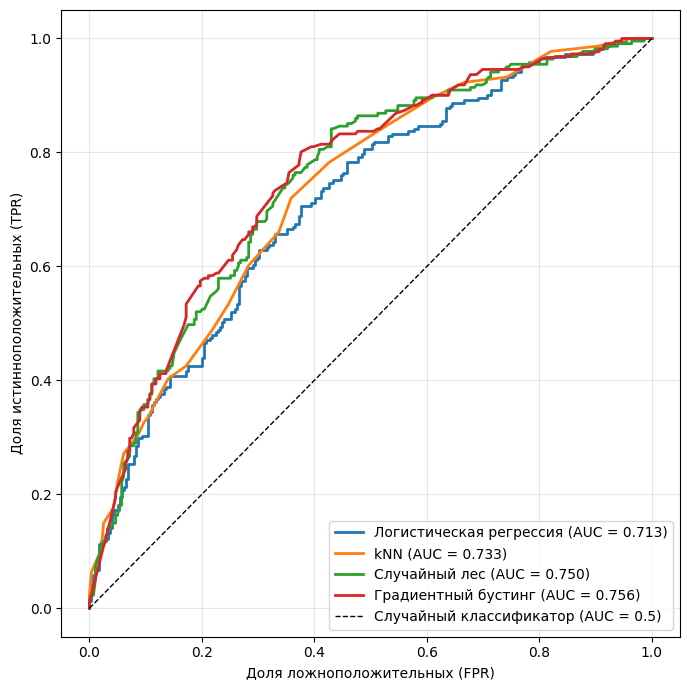

AUC на тестовой выборке (по убыванию):
  Градиентный бустинг: 0.756
  Случайный лес: 0.75
  kNN: 0.733
  Логистическая регрессия: 0.713


In [ ]:
plt.figure(figsize=(7, 7))
auc_summary = []
for name, model in tuned_models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    auc_summary.append((name, round(auc, 3)))
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор (AUC = 0.5)')
plt.xlabel('Доля ложноположительных (FPR)'); plt.ylabel('Доля истинноположительных (TPR)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150); plt.show()

print('AUC на тестовой выборке (по убыванию):')
for name, auc in sorted(auc_summary, key=lambda x: -x[1]):
    print(f'  {name}: {auc}')

### Задание 3.5–3.6. Матрица ошибок и анализ порогов классификации
Для лучшей модели (градиентный бустинг): матрица ошибок при пороге 0.5 и метрики при разных порогах.

Матрица ошибок (Градиентный бустинг, порог 0.5): TN=224, FP=55, FN=96, TP=125



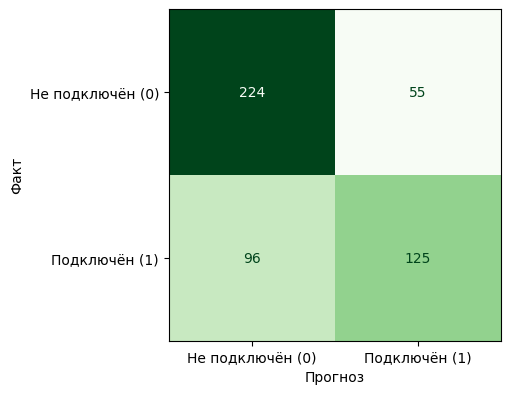

In [ ]:
# 3.5. Матрица ошибок при пороге 0.5
best_name = 'Градиентный бустинг'
proba_test = tuned_models[best_name].predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, (proba_test >= 0.5).astype(int))
tn, fp, fn, tp = cm.ravel()
print(f'Матрица ошибок ({best_name}, порог 0.5): TN={tn}, FP={fp}, FN={fn}, TP={tp}\n')

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['Не подключён (0)', 'Подключён (1)']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_xlabel('Прогноз'); ax.set_ylabel('Факт')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

In [ ]:
# 3.6. Метрики при разных порогах
rows_thr = []
for thr in [0.3, 0.5, 0.7]:
    yp = (proba_test >= thr).astype(int)
    _, fp_, fn_, _ = confusion_matrix(y_test, yp).ravel()
    rows_thr.append({'Порог': thr, 'ACC': round(accuracy_score(y_test, yp), 3),
                     'Precision': round(precision_score(y_test, yp), 3),
                     'Recall': round(recall_score(y_test, yp), 3), 'FP': fp_, 'FN': fn_})
print('Метрики при разных порогах классификации\n')
print(pd.DataFrame(rows_thr).to_string(index=False))

Метрики при разных порогах классификации

 Порог   ACC  Precision  Recall  FP  FN
   0.3 0.602      0.529   0.910 179  20
   0.5 0.698      0.694   0.566  55  96
   0.7 0.646      0.762   0.290  20 157


### Задание 3.7. Прикладная задача: прибыль и оптимальный порог


In [ ]:
# Линейная функция прибыли: TP=+10, FP=-5, FN=0, TN=0
V_TP, C_FP = 10, -5
def profit_linear(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return V_TP * tp + C_FP * fp

thr_grid = np.linspace(0.01, 0.99, 99)
print('Теоретический порог безубыточности = C_FP/(V_TP+C_FP) =', round(5 / 15, 3))

Теоретический порог безубыточности = C_FP/(V_TP+C_FP) = 0.333


In [ ]:
rows_profit = []
for name, m in tuned_models.items():
    p_tr, p_te = m.predict_proba(X_train)[:, 1], m.predict_proba(X_test)[:, 1]
    t_opt = thr_grid[int(np.argmax([profit_linear(y_train, (p_tr >= t).astype(int)) for t in thr_grid]))]
    rows_profit.append({'Метод': name, 'Опт. порог (train)': round(t_opt, 2),
                        'Прибыль test (опт)': profit_linear(y_test, (p_te >= t_opt).astype(int)),
                        'Прибыль test (0.5)': profit_linear(y_test, (p_te >= 0.5).astype(int))})
print('Прибыль (линейная функция)\n')
print(pd.DataFrame(rows_profit).to_string(index=False))

Прибыль (линейная функция)

                  Метод  Опт. порог (train)  Прибыль test (опт)  Прибыль test (0.5)
Логистическая регрессия                0.40                1085                 685
                    kNN                0.30                1130                 835
          Случайный лес                0.38                1200                 740
    Градиентный бустинг                0.31                1140                 975


**Повышенная сложность:** собственная нелинейная функция прибыли.

In [ ]:
# Повышенная: нелинейная прибыль, TP_i = 2*EmployeeCount_i
ec_tr, ec_te = X_train['EmployeeCount'].values, X_test['EmployeeCount'].values
def profit_nonlin(y_true, y_pred, ec):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = (y_pred == 1) & (y_true == 1); fp = (y_pred == 1) & (y_true == 0)
    return (2 * ec[tp]).sum() + C_FP * fp.sum()

rows_profit_nl = []
for name, m in tuned_models.items():
    p_tr, p_te = m.predict_proba(X_train)[:, 1], m.predict_proba(X_test)[:, 1]
    t_opt = thr_grid[int(np.argmax([profit_nonlin(y_train.values, (p_tr >= t).astype(int), ec_tr) for t in thr_grid]))]
    rows_profit_nl.append({'Метод': name, 'Опт. порог (train)': round(t_opt, 2),
                           'Прибыль test (опт)': profit_nonlin(y_test.values, (p_te >= t_opt).astype(int), ec_te)})
print('Прибыль (нелинейная функция, TP_i = 2*EmployeeCount_i)\n')
print(pd.DataFrame(rows_profit_nl).to_string(index=False))

Прибыль (нелинейная функция, TP_i = 2*EmployeeCount_i)

                  Метод  Опт. порог (train)  Прибыль test (опт)
Логистическая регрессия                0.40                1265
                    kNN                0.30                1310
          Случайный лес                0.38                1322
    Градиентный бустинг                0.36                1312


### Задание 3.8. DAG и байесовская сеть
**Повышенная сложность:** AUC байесовской сети.

In [ ]:
feats = ['PilotVoucher', 'BusinessAge', 'EmployeeCount', 'OnlineSuitable']
bins = {'BA': [-1] + list(np.quantile(X_train['BusinessAge'], [.25, .5, .75])) + [1e9],
        'EC': [-1] + list(np.quantile(X_train['EmployeeCount'], [.25, .5, .75])) + [1e9]}
def discretize(Xdf):
    o = pd.DataFrame(index=Xdf.index)
    o['PilotVoucher']   = Xdf['PilotVoucher'].astype(int)
    o['OnlineSuitable'] = Xdf['OnlineSuitable'].astype(int)
    o['BusinessAge']    = pd.cut(Xdf['BusinessAge'],   bins=bins['BA'], labels=False, include_lowest=True).astype(int)
    o['EmployeeCount']  = pd.cut(Xdf['EmployeeCount'], bins=bins['EC'], labels=False, include_lowest=True).astype(int)
    return o
bn_tr = discretize(X_train); bn_tr['MarketplaceAdoption'] = y_train.values
bn_te = discretize(X_test);  bn_te['MarketplaceAdoption'] = y_test.values
state_names = {'PilotVoucher': [0, 1], 'OnlineSuitable': [0, 1], 'BusinessAge': [0, 1, 2, 3],
               'EmployeeCount': [0, 1, 2, 3], 'MarketplaceAdoption': [0, 1]}

def eval_bn(edge_list, name):
    bn = DiscreteBayesianNetwork(edge_list)
    for v in feats + ['MarketplaceAdoption']:
        if v not in bn.nodes(): bn.add_node(v)
    est = BayesianEstimator(bn, bn_tr, state_names=state_names)
    bn.add_cpds(*est.get_parameters(prior_type='BDeu', equivalent_sample_size=10))
    inf = VariableElimination(bn)
    probs = [inf.query(['MarketplaceAdoption'],
                       evidence={f: int(r[f]) for f in feats if f in bn.nodes()},
                       show_progress=False).values[1] for _, r in bn_te.iterrows()]
    probs = np.array(probs)
    print(f'{name}: ACC={accuracy_score(bn_te["MarketplaceAdoption"], (probs >= 0.5).astype(int)):.3f}, '
          f'AUC={roc_auc_score(bn_te["MarketplaceAdoption"], probs):.3f}')

eval_bn([(f, 'MarketplaceAdoption') for f in feats], 'Наш DAG (признаки -> D)')
learned = HillClimbSearch(bn_tr).estimate(scoring_method=BIC(bn_tr), show_progress=False)
print('Обученные рёбра:', list(learned.edges()))
eval_bn(list(learned.edges()), 'Обученный DAG')

Наш DAG (признаки -> D): ACC=0.656, AUC=0.704
Обученные рёбра: [('PilotVoucher', 'MarketplaceAdoption'), ('OnlineSuitable', 'MarketplaceAdoption')]
Обученный DAG: ACC=0.656, AUC=0.690


### Задание 3.9. Выбор лучшего и худшего классификатора
Критерий: основной — Test AUC, вспомогательный — Test accuracy.

In [ ]:
rows_summary = []
for name, m in tuned_models.items():
    proba = m.predict_proba(X_test)[:, 1]
    rows_summary.append({'Метод': name,
                         'Test ACC': round(accuracy_score(y_test, m.predict(X_test)), 3),
                         'Test F1':  round(f1_score(y_test, m.predict(X_test)), 3),
                         'Test AUC': round(roc_auc_score(y_test, proba), 3)})
summary_clf = pd.DataFrame(rows_summary).sort_values('Test AUC', ascending=False)
print('Сводное качество классификаторов на тестовой выборке\n')
print(summary_clf.to_string(index=False))

Сводное качество классификаторов на тестовой выборке

                  Метод  Test ACC  Test F1  Test AUC
    Градиентный бустинг     0.698    0.623     0.756
          Случайный лес     0.666    0.530     0.750
                    kNN     0.656    0.578     0.733
Логистическая регрессия     0.644    0.514     0.713


In [ ]:
print(f"Лучший: {summary_clf.iloc[0]['Метод']} (AUC={summary_clf.iloc[0]['Test AUC']})")
print(f"Худший: {summary_clf.iloc[-1]['Метод']} (AUC={summary_clf.iloc[-1]['Test AUC']})")

Лучший: Градиентный бустинг (AUC=0.756)
Худший: Логистическая регрессия (AUC=0.713)


### Задание 3.10 (повышенная сложность). Дополнительный метод — CatBoost (не из scikit-learn)

In [ ]:
best_cfg_cb, best_cv_cb = None, -1
for depth in [2, 4, 6]:
    for lr in [0.03, 0.1]:
      for n_estimator in [100, 300]: #100 and 300, тк было у град бустинга столько же
        cb = CatBoostClassifier(iterations=n_estimator, depth=depth, learning_rate=lr, verbose=0, random_state=42)
        score = cross_val_score(cb, X_train, y_train, cv=cv, scoring='accuracy').mean()
        if score > best_cv_cb:
            best_cv_cb, best_cfg_cb = score, (depth, lr, n_estimator)

depth, lr, n_estimator = best_cfg_cb
cat = CatBoostClassifier(iterations=n_estimator, depth=depth, learning_rate=lr, verbose=0, random_state=42).fit(X_train, y_train)
print(f'CatBoost: depth={depth}, lr={lr}, iterations={n_estimator}')
print(f'CV ACC={best_cv_cb:.3f} | Test ACC={accuracy_score(y_test, cat.predict(X_test)):.3f} | '
      f'Test AUC={roc_auc_score(y_test, cat.predict_proba(X_test)[:, 1]):.3f}')

gb_best = tuned_models['Градиентный бустинг']
gb_cv_acc = next(r['CV (тюн.)'] for r in rows_clf if r['Метод'] == 'Градиентный бустинг')  # CV-точность из Таблицы 4
print(f'Градиентный бустинг (лучший ранее): CV ACC={gb_cv_acc:.3f} | '
      f'Test ACC={accuracy_score(y_test, gb_best.predict(X_test)):.3f} | '
      f'Test AUC={roc_auc_score(y_test, gb_best.predict_proba(X_test)[:, 1]):.3f}')

CatBoost: depth=2, lr=0.1, iterations=100
CV ACC=0.686 | Test ACC=0.692 | Test AUC=0.757
Градиентный бустинг (лучший ранее): CV ACC=0.677 | Test ACC=0.698 | Test AUC=0.756


## Раздел 4. Регрессия
Признаки (задание 4.1): PilotVoucher, BusinessAge, EmployeeCount, OnlineSuitable; целевая — Revenue. Переменная воздействия D и ненаблюдаемая U в признаки не включаются.

### Задание 4.2. Базовое качество (RMSE, MAPE), тюнинг по CV, переобучение


In [ ]:
FEATURES_REG, TARGET_REG = ['PilotVoucher', 'BusinessAge', 'EmployeeCount', 'OnlineSuitable'], 'Revenue'
Xr_train, yr_train = train_df[FEATURES_REG], train_df[TARGET_REG]
Xr_test,  yr_test  = test_df[FEATURES_REG],  test_df[TARGET_REG]
print(f'Ориентир: RMSE тривиального прогноза (средняя) = СКО выручки = {yr_test.std():.1f}\n')

Ориентир: RMSE тривиального прогноза (средняя) = СКО выручки = 358.2



In [ ]:
def make_reg():
    return {'МНК': Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
            'kNN': Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=5))]),
            'Случайный лес': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            'Градиентный бустинг': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                             max_depth=3, random_state=42)}

init_params_reg = {'МНК': '—', 'kNN': 'k=5', 'Случайный лес': 'n=100, depth=None',
                   'Градиентный бустинг': 'n=100, lr=0.1, depth=3'}
grids_reg = {'МНК': {}, 'kNN': {'m__n_neighbors': [5, 11, 21, 31]},
             'Случайный лес': {'n_estimators': [200], 'max_depth': [3, 5, 8, None],
                               'min_samples_leaf': [1, 5, 10]},
             'Градиентный бустинг': {'n_estimators': [100, 300], 'learning_rate': [0.03, 0.1],
                                     'max_depth': [2, 3]}}

def reg_metrics(est):
    """RMSE и MAPE на train, по CV и на test для одной модели."""
    est.fit(Xr_train, yr_train)
    rmse_tr = rmse(yr_train, est.predict(Xr_train))
    rmse_te = rmse(yr_test,  est.predict(Xr_test))
    rmse_cv = -cross_val_score(est, Xr_train, yr_train, cv=kf,
                               scoring='neg_root_mean_squared_error').mean()
    mape_tr = mean_absolute_percentage_error(yr_train, est.predict(Xr_train))
    mape_te = mean_absolute_percentage_error(yr_test,  est.predict(Xr_test))
    mape_cv = -cross_val_score(est, Xr_train, yr_train, cv=kf,
                               scoring='neg_mean_absolute_percentage_error').mean()
    return rmse_tr, rmse_cv, rmse_te, mape_tr, mape_cv, mape_te

rows_reg = []
for name in make_reg():
    # исходные гиперпараметры
    r_tr, r_cv0, r_te0, m_tr, m_cv0, m_te0 = reg_metrics(make_reg()[name])

    # тюнинг по CV (RMSE)
    if grids_reg[name]:
        gs = GridSearchCV(make_reg()[name], grids_reg[name], cv=kf,
                          scoring='neg_root_mean_squared_error', n_jobs=-1).fit(Xr_train, yr_train)
        best, bp = gs.best_estimator_, str(gs.best_params_)
    else:
        best, bp = make_reg()[name], '—'

    # метрики подобранной модели (в т.ч. CV после тюнинга)
    _, r_cv1, r_te1, _, m_cv1, m_te1 = reg_metrics(best)

    rows_reg.append({'Метод': name, 'Исходные': init_params_reg[name], 'Подобранные': bp,
                     'RMSE train (исх.)': round(r_tr, 1),
                     'RMSE CV (исх.)':   round(r_cv0, 1),
                     'RMSE test (исх.)': round(r_te0, 1),
                     'RMSE CV (тюн.)':   round(r_cv1, 1),
                     'RMSE test (тюн.)': round(r_te1, 1),
                     'MAPE train (исх.)': round(m_tr, 3),
                     'MAPE CV (исх.)':   round(m_cv0, 3),
                     'MAPE test (исх.)': round(m_te0, 3),
                     'MAPE CV (тюн.)':   round(m_cv1, 3),
                     'MAPE test (тюн.)': round(m_te1, 3)})

print('Качество регрессионных моделей\n')
print(pd.DataFrame(rows_reg).to_string(index=False))

Качество регрессионных моделей

              Метод               Исходные                                                   Подобранные  RMSE train (исх.)  RMSE CV (исх.)  RMSE test (исх.)  RMSE CV (тюн.)  RMSE test (тюн.)  MAPE train (исх.)  MAPE CV (исх.)  MAPE test (исх.)  MAPE CV (тюн.)  MAPE test (тюн.)
                МНК                      —                                                             —              368.6           366.9             334.3           366.9             334.3              0.960           0.965             0.997           0.965             0.997
                kNN                    k=5                                        {'m__n_neighbors': 31}              327.5           396.4             366.9           371.2             331.5              0.809           0.977             1.071           0.964             1.011
      Случайный лес      n=100, depth=None {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200}              156.9        

**Повышенная сложность:** подбор градиентного бустинга по OOB-ошибке.

In [ ]:
# Повышенная: OOB для градиентного бустинга
gb_sub = GradientBoostingRegressor(n_estimators=500, learning_rate=0.03, max_depth=2,
                                   subsample=0.8, random_state=42).fit(Xr_train, yr_train)
best_n = int(np.argmax(np.cumsum(gb_sub.oob_improvement_))) + 1
gb_oob = GradientBoostingRegressor(n_estimators=best_n, learning_rate=0.03, max_depth=2,
                                   subsample=0.8, random_state=42).fit(Xr_train, yr_train)
print(f'OOB: n_estimators={best_n}, RMSE test={rmse(yr_test, gb_oob.predict(Xr_test)):.1f}')

OOB: n_estimators=153, RMSE test=335.7


### Задание 4.3. Выбор лучшей и худшей регрессионной модели
Критерий: основной — Test RMSE, вспомогательный — Test MAPE.

In [ ]:
summary_reg = (pd.DataFrame(rows_reg)[['Метод', 'RMSE test (тюн.)', 'MAPE test (тюн.)']]
               .rename(columns={'RMSE test (тюн.)': 'RMSE test', 'MAPE test (тюн.)': 'MAPE test'})
               .sort_values('RMSE test'))
print('Итоговое качество регрессионных моделей\n')
print(summary_reg.to_string(index=False))

Итоговое качество регрессионных моделей

              Метод  RMSE test  MAPE test
                kNN      331.5      1.011
                МНК      334.3      0.997
Градиентный бустинг      336.6      1.056
      Случайный лес      337.3      1.044


In [ ]:
print(f"Лучшая: {summary_reg.iloc[0]['Метод']} (RMSE={summary_reg.iloc[0]['RMSE test']})")
print(f"Худшая: {summary_reg.iloc[-1]['Метод']} (RMSE={summary_reg.iloc[-1]['RMSE test']})")

Лучшая: kNN (RMSE=331.5)
Худшая: Случайный лес (RMSE=337.3)


### Задание 4.4 (повышенная сложность). Дополнительный метод — CatBoostRegressor

In [ ]:
best_cfg_cbr, best_cv_cbr = None, 1e18
for depth in [2, 4, 6]:
    for lr in [0.03, 0.1]:
      for n_estimator in [100, 300]:
        cb = CatBoostRegressor(iterations=n_estimator, depth=depth, learning_rate=lr, verbose=0, random_state=42)
        score = -cross_val_score(cb, Xr_train, yr_train, cv=kf, scoring='neg_root_mean_squared_error').mean()
        if score < best_cv_cbr:
            best_cv_cbr, best_cfg_cbr = score, (depth, lr, n_estimator)

depth, lr, n_estimator = best_cfg_cbr
cbr = CatBoostRegressor(iterations=n_estimator, depth=depth, learning_rate=lr, verbose=0, random_state=42).fit(Xr_train, yr_train)
print(f'CatBoostRegressor: depth={depth}, lr={lr}, iterations={n_estimator}')
print(f'CV RMSE={best_cv_cbr:.1f} | Test RMSE={rmse(yr_test, cbr.predict(Xr_test)):.1f} | '
      f'Test MAPE={mean_absolute_percentage_error(yr_test, cbr.predict(Xr_test)):.3f}')

CatBoostRegressor: depth=2, lr=0.03, iterations=300
CV RMSE=367.9 | Test RMSE=335.2 | Test MAPE=1.004


## Раздел 5. Эффекты воздействия

### Задание 5.1. ATE и LATE: обозначения и формулы

В разделе используются следующие обозначения:

- $Y = Revenue$ — месячная выручка малого бизнеса.
- $D = MarketplaceAdoption$ — индикатор подключения бизнеса к маркетплейсу.
- $Z = PilotVoucher$ — индикатор получения пилотного ваучера, используемый как инструмент.
- $X = (BusinessAge, EmployeeCount, OnlineSuitable)$ — наблюдаемые контрольные переменные.
- $Y(1)$ и $Y(0)$ — потенциальные исходы выручки при подключении и без подключения к маркетплейсу.
- $D(1)$ и $D(0)$ — потенциальные статусы подключения при $Z = 1$ и $Z = 0$.

Средний эффект воздействия для всех бизнесов:

$$
ATE = \mathbb{E}[Y(1) - Y(0)].
$$

Локальный средний эффект воздействия для compliers:

$$
LATE = \mathbb{E}[Y(1) - Y(0) \mid D(1) > D(0)].
$$

**Интерпретация.** $ATE$ показывает средний эффект подключения к маркетплейсу для всех бизнесов в выборке. $LATE$ показывает средний эффект для *compliers*, то есть для тех бизнесов, которые подключаются именно из-за получения ваучера $PilotVoucher$.


In [ ]:
# Задание 5.1. Общая выборка, обозначения и вспомогательные модели раздела 5.
# Объединяем train и test обратно в одну выборку. Начиная с 5.3 используем только
# наблюдаемые переменные; потенциальные исходы и U участвуют лишь в эталоне 5.2.

section5_df = pd.concat([train_df, test_df]).sort_index()

CONTROLS = ['BusinessAge', 'EmployeeCount', 'OnlineSuitable']
Y = section5_df['Revenue'].astype(float)            # исход
D = section5_df['MarketplaceAdoption'].astype(int)  # воздействие
Z = section5_df['PilotVoucher'].astype(int)         # инструмент
W = section5_df[CONTROLS]                            # наблюдаемые контроли

# Лучшие/худшие модели из разделов 3 и 4 — используются как nuisance-модели ниже.
best_clf_name, worst_clf_name = summary_clf.iloc[0]['Метод'], summary_clf.iloc[-1]['Метод']
best_reg_name, worst_reg_name = summary_reg.iloc[0]['Метод'], summary_reg.iloc[-1]['Метод']

In [ ]:
print(f'Число наблюдений: {len(section5_df)}')
print(f'Исход Y: {Y.name}; воздействие D: {D.name}; инструмент Z: {Z.name}')
print(f'Контроли W: {CONTROLS}')
print(f'Лучшие модели  — классификатор: {best_clf_name}, регрессор: {best_reg_name}')
print(f'Худшие модели  — классификатор: {worst_clf_name}, регрессор: {worst_reg_name}')

Число наблюдений: 2000
Исход Y: Revenue; воздействие D: MarketplaceAdoption; инструмент Z: PilotVoucher
Контроли W: ['BusinessAge', 'EmployeeCount', 'OnlineSuitable']
Лучшие модели  — классификатор: Градиентный бустинг, регрессор: kNN
Худшие модели  — классификатор: Логистическая регрессия, регрессор: Случайный лес


### Задание 5.2. Истинные эффекты по потенциальным исходам

В этом пункте используются симулированные потенциальные исходы и потенциальные статусы воздействия. В реальных данных такие переменные ненаблюдаемы, поэтому этот блок служит эталоном для сравнения с оценками по наблюдаемым данным в следующих заданиях.


In [ ]:
# Задание 5.2. Истинные ATE, LATE и распределение индивидуальных эффектов.
# Единственный пункт раздела 5, где используются потенциальные исходы Y1, Y0, D1, D0 и Complier.

ite = full_df['Y1'] - full_df['Y0']            # индивидуальный эффект воздействия
true_ate = ite.mean()                          # истинный ATE — средний эффект по всем фирмам
complier_mask = full_df['Complier'] == 1
true_late = ite[complier_mask].mean()          # истинный LATE — средний эффект для compliers
complier_share = complier_mask.mean()

true_effects_table = pd.DataFrame({
    'Эффект': ['ATE', 'LATE'],
    'Оценка, тыс. руб.': [round(true_ate, 2), round(true_late, 2)],
    'Интерпретация': [
        'Средний эффект подключения к маркетплейсу для всех бизнесов.',
        'Средний эффект для compliers: бизнесов, подключающихся из-за ваучера PilotVoucher.',
    ],
})
print('Истинные ATE и LATE по потенциальным исходам\n')
display(true_effects_table)
print(f'Доля compliers в выборке: {complier_share:.3f}')

Истинные ATE и LATE по потенциальным исходам



,Эффект,"Оценка, тыс. руб.",Интерпретация
0,ATE,175.58,Средний эффект подключения к маркетплейсу для всех бизнесов.
1,LATE,158.86,"Средний эффект для compliers: бизнесов, подключающихся из-за ваучера PilotVoucher."


Доля compliers в выборке: 0.325


In [ ]:
cate_online_table = (full_df.assign(ITE=ite)
                     .groupby('OnlineSuitable', as_index=False)
                     .agg(**{'Средний ITE, тыс. руб.': ('ITE', 'mean'),
                             'Количество наблюдений': ('ITE', 'size')}))
cate_online_table['Средний ITE, тыс. руб.'] = cate_online_table['Средний ITE, тыс. руб.'].round(2)
print('Истинный CATE по группам OnlineSuitable\n')
display(cate_online_table)

Истинный CATE по группам OnlineSuitable



,OnlineSuitable,"Средний ITE, тыс. руб.",Количество наблюдений
0,0,102.99,866
1,1,231.02,1134


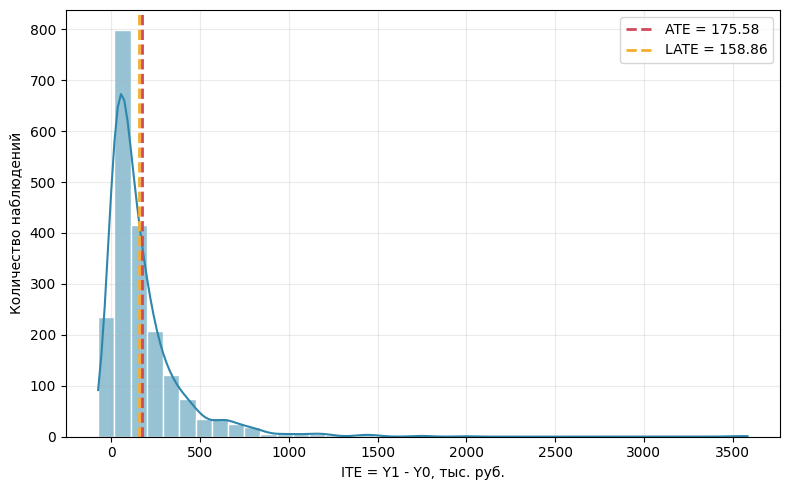

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(ite, bins=40, kde=True, color='#2E86AB', edgecolor='white')
plt.axvline(true_ate, color='#D1495B', linestyle='--', linewidth=2, label=f'ATE = {true_ate:.2f}')
plt.axvline(true_late, color='#F6AE2D', linestyle='--', linewidth=2, label=f'LATE = {true_late:.2f}')
plt.xlabel('ITE = Y1 - Y0, тыс. руб.'); plt.ylabel('Количество наблюдений')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout()
plt.savefig('section5_ite_distribution.png', dpi=150); plt.show()

### Задание 5.3. Наивная разница средних

Наивная разница средних сравнивает среднюю выручку бизнесов, которые подключились к маркетплейсу, со средней выручкой бизнесов без подключения. Эта оценка может быть смещена из-за эндогенности: ненаблюдаемая переменная $EntrepreneurialAbility$ влияет и на вероятность подключения $MarketplaceAdoption$, и на выручку $Revenue$. Поэтому различие средних смешивает причинный эффект подключения с исходными различиями между бизнесами.


In [ ]:
# Задание 5.3. Наивная оценка ATE как разница средней выручки при D=1 и D=0.
# Начиная с этого пункта используем только наблюдаемые переменные (Y, D, W).
mean_revenue_d1 = Y[D == 1].mean()
mean_revenue_d0 = Y[D == 0].mean()
naive_diff = mean_revenue_d1 - mean_revenue_d0

naive_group_table = pd.DataFrame({
    'Группа': ['D=1: подключены', 'D=0: не подключены'],
    'Средняя Revenue, тыс. руб.': [round(mean_revenue_d1, 2), round(mean_revenue_d0, 2)],
    'Количество наблюдений': [int((D == 1).sum()), int((D == 0).sum())],
})
print('Средняя выручка по группам фактического подключения\n')
display(naive_group_table)

Средняя выручка по группам фактического подключения



,Группа,"Средняя Revenue, тыс. руб.",Количество наблюдений
0,D=1: подключены,570.87,895
1,D=0: не подключены,206.07,1105


In [ ]:
naive_comparison_table = pd.DataFrame([{
    'Метод': 'Наивная разница средних',
    'Оценка ATE, тыс. руб.': round(naive_diff, 2),
    'Истинный ATE, тыс. руб.': round(true_ate, 2),
    'Смещение относительно истинного ATE, тыс. руб.': round(naive_diff - true_ate, 2),
}])
print('Таблица 20. Наивная оценка ATE и сравнение с истинным ATE\n')
display(naive_comparison_table)

Таблица 20. Наивная оценка ATE и сравнение с истинным ATE



,Метод,"Оценка ATE, тыс. руб.","Истинный ATE, тыс. руб.","Смещение относительно истинного ATE, тыс. руб."
0,Наивная разница средних,364.8,175.58,189.22


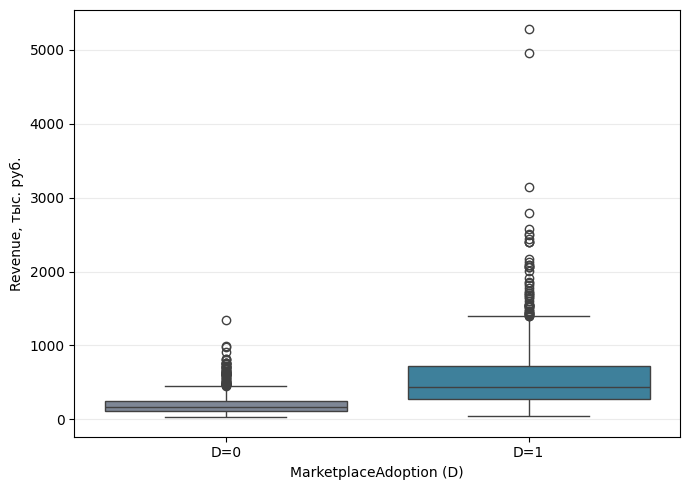

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=section5_df, x='MarketplaceAdoption', y='Revenue', palette=['#7A869A', '#2E86AB'])
plt.xlabel('MarketplaceAdoption (D)'); plt.ylabel('Revenue, тыс. руб.')
plt.xticks([0, 1], ['D=0', 'D=1']); plt.grid(axis='y', alpha=0.25); plt.tight_layout()
plt.savefig('section5_naive_revenue_by_d.png', dpi=150); plt.show()

### Задание 5.4. ATE по наблюдаемым данным с использованием ML-моделей

В этом пункте оцениваем средний эффект подключения к маркетплейсу по наблюдаемым данным методами OLS, conditional expectations / T-learner, IPW, AIPW и DML без инструментальной переменной. Ключевая предпосылка этих методов — условная независимость воздействия (*conditional independence*, *unconfoundedness*): после контроля за $X = (BusinessAge, EmployeeCount, OnlineSuitable)$ подключение к маркетплейсу должно быть как бы случайным относительно потенциальных исходов. В нашем DGP эта предпосылка нарушается, потому что ненаблюдаемая $EntrepreneurialAbility$ влияет и на $MarketplaceAdoption$, и на $Revenue$. Поэтому оценки без IV ожидаемо могут быть завышены.

В этом пункте $PilotVoucher$ не включается в $X$: ваучер будет использоваться отдельно как инструмент в IV-оценках, а здесь сравнение строится только по наблюдаемым контролям бизнеса.


In [ ]:
def make_regressor(model_name, n_obs=None):
    """Регрессор того же типа, что и настроенные модели раздела 4."""
    if model_name == 'МНК':
        return Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])
    if model_name == 'kNN':
        k = min(31, max(1, int(n_obs))) if n_obs is not None else 31
        return Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=k))])
    if model_name == 'Случайный лес':
        return RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=10,
                                     random_state=42, n_jobs=-1)
    return GradientBoostingRegressor(n_estimators=100, learning_rate=0.03,
                                     max_depth=2, random_state=42)

In [ ]:
def make_classifier(model_name, n_obs=None):
    """Классификатор того же типа, что и настроенные модели раздела 3."""
    if model_name == 'Логистическая регрессия':
        return Pipeline([('sc', StandardScaler()),
                         ('clf', LogisticRegression(C=0.01, max_iter=1000))])
    if model_name == 'kNN':
        k = min(31, max(1, int(n_obs))) if n_obs is not None else 31
        return Pipeline([('sc', StandardScaler()),
                         ('clf', KNeighborsClassifier(n_neighbors=k, weights='uniform'))])
    if model_name == 'Случайный лес':
        return RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=1,
                                      random_state=42, n_jobs=-1)
    return GradientBoostingClassifier(n_estimators=100, learning_rate=0.03,
                                      max_depth=3, random_state=42)

In [ ]:
# Задание 5.4. Оценки ATE по наблюдаемым данным: OLS, T-learner, IPW, AIPW и DML без IV.
# Все nuisance-модели обучаются на контролях W (без PilotVoucher) при допущении
# условной независимости (conditional independence).

# 1. OLS: Revenue ~ D + W; ATE — коэффициент при D.
ate_ols = LinearRegression().fit(pd.concat([D.rename('D'), W], axis=1), Y).coef_[0]

# 2. T-learner: отдельные модели E[Y|D=1, W] и E[Y|D=0, W].
m1 = make_regressor(best_reg_name, n_obs=int((D == 1).sum())).fit(W[D == 1], Y[D == 1])
m0 = make_regressor(best_reg_name, n_obs=int((D == 0).sum())).fit(W[D == 0], Y[D == 0])
m1_hat = pd.Series(m1.predict(W), index=W.index)
m0_hat = pd.Series(m0.predict(W), index=W.index)
ate_tlearner = (m1_hat - m0_hat).mean()

# 3. IPW: propensity score e(W) = P(D=1|W) с обрезкой крайних значений.
e_hat = pd.Series(make_classifier(best_clf_name).fit(W, D).predict_proba(W)[:, 1],
                  index=W.index).clip(0.01, 0.99)
ate_ipw = (D * Y / e_hat - (1 - D) * Y / (1 - e_hat)).mean()

# 4. AIPW (doubly robust): объединяет outcome-модели и propensity score.
ate_aipw = (m1_hat - m0_hat
            + D * (Y - m1_hat) / e_hat
            - (1 - D) * (Y - m0_hat) / (1 - e_hat)).mean()

# 5. DML без IV: cross-fitting остатков Y и D по W, затем частичная регрессия.
m_hat = pd.Series(index=W.index, dtype=float)
e_hat_cf = pd.Series(index=W.index, dtype=float)
for tr, te in kf.split(W):
    i_tr, i_te = W.index[tr], W.index[te]
    m_hat.loc[i_te] = make_regressor(best_reg_name, n_obs=len(i_tr)).fit(
        W.loc[i_tr], Y.loc[i_tr]).predict(W.loc[i_te])
    e_hat_cf.loc[i_te] = make_classifier(best_clf_name).fit(
        W.loc[i_tr], D.loc[i_tr]).predict_proba(W.loc[i_te])[:, 1]
e_hat_cf = e_hat_cf.clip(0.01, 0.99)
d_res = D - e_hat_cf
ate_dml = (d_res * (Y - m_hat)).sum() / (d_res ** 2).sum()

In [ ]:
ate_table = pd.DataFrame({
    'Метод': ['OLS / МНК', 'Conditional expectations / T-learner', 'IPW',
              'Doubly robust / AIPW', 'DML без IV'],
    'Оценка ATE, тыс. руб.': [ate_ols, ate_tlearner, ate_ipw, ate_aipw, ate_dml],
})
ate_table['Истинный ATE, тыс. руб.'] = true_ate
ate_table['Смещение относительно истинного ATE, тыс. руб.'] = ate_table['Оценка ATE, тыс. руб.'] - true_ate
for col in ate_table.select_dtypes('number').columns:
    ate_table[col] = ate_table[col].round(2)
print('Оценки ATE: OLS, T-learner, IPW, AIPW и DML без IV\n')
display(ate_table)

Оценки ATE: OLS, T-learner, IPW, AIPW и DML без IV



,Метод,"Оценка ATE, тыс. руб.","Истинный ATE, тыс. руб.","Смещение относительно истинного ATE, тыс. руб."
0,OLS / МНК,336.88,175.58,161.30
1,Conditional expectations / T-learner,339.47,175.58,163.89
2,IPW,313.75,175.58,138.17
3,Doubly robust / AIPW,339.97,175.58,164.38
4,DML без IV,342.23,175.58,166.64


In [ ]:
propensity_summary = pd.DataFrame({
    'Показатель': ['min e_hat', 'mean e_hat', 'max e_hat'],
    'Значение': [round(e_hat.min(), 3), round(e_hat.mean(), 3), round(e_hat.max(), 3)],
})
print('Диагностика propensity score после обрезки\n')
display(propensity_summary)

Диагностика propensity score после обрезки



,Показатель,Значение
0,min e_hat,0.092
1,mean e_hat,0.448
2,max e_hat,0.703


### Задание 5.5. Условные средние эффекты воздействия (CATE)

В этом пункте оцениваем неоднородные эффекты подключения к маркетплейсу: для каждого бизнеса строится индивидуальная оценка $CATE(X)$. Ожидаем, что эффект неоднороден: у бизнесов, для которых онлайн-канал продаж подходит лучше ($OnlineSuitable = 1$), эффект подключения должен быть выше. X-learner особенно полезен при сильном дисбалансе между treatment/control, потому что он по-разному использует информацию из групп $D=1$ и $D=0$. В нашей выборке доля подключившихся около 45%, поэтому преимущество X-learner над S- и T-learner не обязательно будет большим.


In [ ]:
# Задание 5.5. Оценки CATE: МНК с взаимодействиями, S-, T-, transformed outcome и X-learner.
# Используем только наблюдаемые переменные; PilotVoucher как контроль не входит.
def with_interactions(d, W):
    d = pd.Series(d, index=W.index, name='D')
    out = pd.concat([d, W], axis=1)
    for col in CONTROLS:
        out[f'D_x_{col}'] = d * W[col]
    return out

def with_treatment(d, W):
    return pd.concat([pd.Series(d, index=W.index, name='D'), W], axis=1)

# 1. МНК с взаимодействиями: CATE — разница прогнозов при D=1 и D=0.
ols_inter = LinearRegression().fit(with_interactions(D, W), Y)
cate_ols = pd.Series(ols_inter.predict(with_interactions(1, W)) - ols_inter.predict(with_interactions(0, W)),
                     index=W.index, name='МНК с взаимодействиями')

# 2. S-learner: одна outcome-модель на [D, W].
s_model = make_regressor(best_reg_name, n_obs=len(W)).fit(with_treatment(D, W), Y)
cate_s = pd.Series(s_model.predict(with_treatment(1, W)) - s_model.predict(with_treatment(0, W)),
                   index=W.index, name='S-learner')

# 3. T-learner: две outcome-модели, отдельно для treated и control.
m1 = make_regressor(best_reg_name, n_obs=int((D == 1).sum())).fit(W[D == 1], Y[D == 1])
m0 = make_regressor(best_reg_name, n_obs=int((D == 0).sum())).fit(W[D == 0], Y[D == 0])
m1_hat = pd.Series(m1.predict(W), index=W.index)
m0_hat = pd.Series(m0.predict(W), index=W.index)
cate_t = pd.Series(m1_hat - m0_hat, index=W.index, name='T-learner')

# Propensity score для transformed outcome и X-learner.
e_hat = pd.Series(make_classifier(best_clf_name).fit(W, D).predict_proba(W)[:, 1],
                  index=W.index).clip(0.01, 0.99)

# 4. Transformed outcome: регрессия преобразованного исхода на W.
y_trans = Y * (D - e_hat) / (e_hat * (1 - e_hat))
cate_transformed = pd.Series(make_regressor(best_reg_name, n_obs=len(W)).fit(W, y_trans).predict(W),
                             index=W.index, name='Transformed outcome')

# 5. X-learner: tau(x) = e(x)*tau0(x) + (1 - e(x))*tau1(x).
d1_tilde = Y[D == 1] - pd.Series(m0.predict(W[D == 1]), index=W[D == 1].index)
d0_tilde = pd.Series(m1.predict(W[D == 0]), index=W[D == 0].index) - Y[D == 0]
tau1 = make_regressor(best_reg_name, n_obs=int((D == 1).sum())).fit(W[D == 1], d1_tilde)
tau0 = make_regressor(best_reg_name, n_obs=int((D == 0).sum())).fit(W[D == 0], d0_tilde)
tau1_hat = pd.Series(tau1.predict(W), index=W.index)
tau0_hat = pd.Series(tau0.predict(W), index=W.index)
cate_x = pd.Series(e_hat * tau0_hat + (1 - e_hat) * tau1_hat, index=W.index, name='X-learner')

cate_estimates = pd.concat([cate_ols, cate_s, cate_t, cate_transformed, cate_x], axis=1)

cate_summary = (cate_estimates.agg(['mean', 'std', 'min', 'median', 'max']).T
                .reset_index()
                .rename(columns={'index': 'Метод', 'mean': 'Средний CATE, тыс. руб.',
                                 'std': 'Стандартное отклонение CATE', 'min': 'Минимум',
                                 'median': 'Медиана', 'max': 'Максимум'}))
for col in cate_summary.select_dtypes('number').columns:
    cate_summary[col] = cate_summary[col].round(2)
print('Распределение оценок CATE по методам\n')
display(cate_summary)

Распределение оценок CATE по методам



,Метод,"Средний CATE, тыс. руб.",Стандартное отклонение CATE,Минимум,Медиана,Максимум
0,МНК с взаимодействиями,331.19,136.34,3.86,335.99,833.04
1,S-learner,334.71,146.11,75.51,310.05,769.88
2,T-learner,339.47,146.53,121.15,311.43,762.14
3,Transformed outcome,329.92,229.53,-494.40,295.77,1148.04
4,X-learner,340.57,138.56,136.18,317.19,753.48


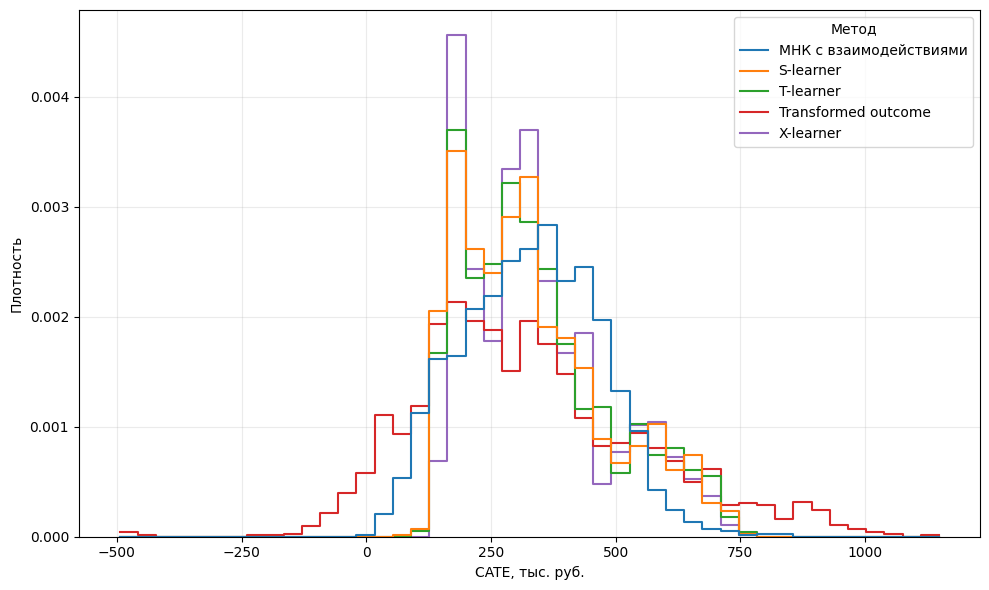

In [ ]:
cate_long = cate_estimates.reset_index(drop=True).melt(var_name='Метод', value_name='CATE, тыс. руб.')
plt.figure(figsize=(10, 6))
sns.histplot(data=cate_long, x='CATE, тыс. руб.', hue='Метод', bins=45,
             element='step', stat='density', common_norm=False, fill=False)
plt.xlabel('CATE, тыс. руб.'); plt.ylabel('Плотность'); plt.grid(alpha=0.25); plt.tight_layout()
plt.savefig('section5_cate_distribution_methods.png', dpi=150); plt.show()

In [ ]:
cate_online_by_method = (pd.concat([W[['OnlineSuitable']].reset_index(drop=True),
                                    cate_estimates.reset_index(drop=True)], axis=1)
                         .melt(id_vars='OnlineSuitable', var_name='Метод', value_name='CATE, тыс. руб.')
                         .groupby(['Метод', 'OnlineSuitable'], as_index=False)
                         .agg(**{'Средний CATE, тыс. руб.': ('CATE, тыс. руб.', 'mean'),
                                 'Количество наблюдений': ('CATE, тыс. руб.', 'size')}))
cate_online_by_method['Средний CATE, тыс. руб.'] = cate_online_by_method['Средний CATE, тыс. руб.'].round(2)
print('Средние CATE по OnlineSuitable\n')
display(cate_online_by_method)

Средние CATE по OnlineSuitable



,Метод,OnlineSuitable,"Средний CATE, тыс. руб.",Количество наблюдений
0,S-learner,0,224.92,866
1,S-learner,1,418.55,1134
2,T-learner,0,229.14,866
3,T-learner,1,423.73,1134
4,Transformed outcome,0,194.81,866
5,Transformed outcome,1,433.10,1134
6,X-learner,0,231.18,866
7,X-learner,1,424.12,1134
8,МНК с взаимодействиями,0,219.86,866
9,МНК с взаимодействиями,1,416.21,1134


### Задание 5.6. LATE: DML без IV и DML-IV

DML без инструментальной переменной устраняет влияние наблюдаемых контролей $W$, но не решает проблему скрытой эндогенности: ненаблюдаемая $EntrepreneurialAbility$ продолжает влиять и на подключение, и на выручку. Поэтому такая оценка остается смещенной как причинная оценка эффекта подключения. DML-IV использует $PilotVoucher$ как отдельный инструмент $Z$: случайная выдача ваучера создает экзогенную вариацию в $MarketplaceAdoption$, по которой можно оценить локальный эффект. Этот эффект отличается от ATE: LATE относится не ко всем фирмам, а к *compliers*, то есть к тем бизнесам, чье подключение меняется из-за инструмента.


In [ ]:
# Задание 5.6. Оценки LATE: DML без IV, DML-IV и Wald-IV.
# Контроли W (без PilotVoucher); PilotVoucher используется строго как инструмент Z.
y_arr, d_arr, z_arr = Y.to_numpy(float), D.to_numpy(float), Z.to_numpy(float)
mY_hat = np.empty_like(y_arr)
mD_hat = np.empty_like(d_arr)
mZ_hat = np.empty_like(z_arr)
for tr, te in kf.split(W):
    W_tr, W_te = W.iloc[tr], W.iloc[te]
    mY_hat[te] = make_regressor(best_reg_name, n_obs=len(tr)).fit(W_tr, y_arr[tr]).predict(W_te)
    mD_hat[te] = make_classifier(best_clf_name).fit(W_tr, d_arr[tr].astype(int)).predict_proba(W_te)[:, 1]
    mZ_hat[te] = make_classifier(best_clf_name).fit(W_tr, z_arr[tr].astype(int)).predict_proba(W_te)[:, 1]

y_res = y_arr - mY_hat
d_res = d_arr - np.clip(mD_hat, 0.01, 0.99)
z_res = z_arr - np.clip(mZ_hat, 0.01, 0.99)

theta_dml = (d_res * y_res).sum() / (d_res ** 2).sum()         # DML без IV
theta_dml_iv = (z_res * y_res).sum() / (z_res * d_res).sum()   # DML-IV

first_stage = d_arr[z_arr == 1].mean() - d_arr[z_arr == 0].mean()
wald_iv = (y_arr[z_arr == 1].mean() - y_arr[z_arr == 0].mean()) / first_stage

In [ ]:
late_table = pd.DataFrame({
    'Метод': ['DML без IV', 'DML-IV', 'Wald-IV'],
    'Оценка LATE / эффекта, тыс. руб.': [theta_dml, theta_dml_iv, wald_iv],
})
late_table['Истинный LATE, тыс. руб.'] = true_late
late_table['Отклонение от истинного LATE, тыс. руб.'] = (
    late_table['Оценка LATE / эффекта, тыс. руб.'] - true_late)
for col in late_table.select_dtypes('number').columns:
    late_table[col] = late_table[col].round(2)
print('Оценки LATE: DML без IV, DML-IV и Wald-IV\n')
display(late_table)

Оценки LATE: DML без IV, DML-IV и Wald-IV



,Метод,"Оценка LATE / эффекта, тыс. руб.","Истинный LATE, тыс. руб.","Отклонение от истинного LATE, тыс. руб."
0,DML без IV,342.23,158.86,183.36
1,DML-IV,174.03,158.86,15.17
2,Wald-IV,136.47,158.86,-22.39


In [ ]:
first_stage_table = pd.DataFrame({
    'Показатель': ['E[D|Z=1]', 'E[D|Z=0]', 'First stage: E[D|Z=1] - E[D|Z=0]',
                   'E[Y|Z=1] - E[Y|Z=0]', 'DML-IV denominator: sum(Z_res*D_res)'],
    'Значение': [d_arr[z_arr == 1].mean(), d_arr[z_arr == 0].mean(), first_stage,
                 y_arr[z_arr == 1].mean() - y_arr[z_arr == 0].mean(), (z_res * d_res).sum()],
})
first_stage_table['Значение'] = first_stage_table['Значение'].round(4)
print('Диагностика инструмента и first stage\n')
display(first_stage_table)

Диагностика инструмента и first stage



,Показатель,Значение
0,E[D|Z=1],0.5834
1,E[D|Z=0],0.3080
2,First stage: E[D|Z=1] - E[D|Z=0],0.2754
3,E[Y|Z=1] - E[Y|Z=0],37.5849
4,DML-IV denominator: sum(Z_res*D_res),143.9645


### Задание 5.7. Устойчивость оценок к качеству ML-моделей

В этом пункте сравниваем оценки, построенные на лучших и худших моделях из разделов классификации и регрессии. Если DML-IV дает близкие результаты при лучших и худших nuisance-моделях, вывод о локальном эффекте можно считать более устойчивым. Если обычные ATE-методы без IV остаются завышенными даже с лучшими ML-моделями, значит главная проблема не в качестве прогнозных алгоритмов, а в нарушении идентификационной предпосылки из-за ненаблюдаемой $EntrepreneurialAbility$. Качество ML влияет на точность nuisance-функций, но не заменяет корректную causal identification strategy.


In [ ]:
# Задание 5.7. Устойчивость оценок ATE/LATE к качеству nuisance-моделей (лучшие vs худшие).
model_choice_table = pd.DataFrame({
    'Задача': ['Propensity / классификация', 'Outcome / регрессия'],
    'Лучшая модель': [best_clf_name, best_reg_name],
    'Худшая модель': [worst_clf_name, worst_reg_name],
})
print('Лучшие и худшие модели, используемые в задании 5.7\n')
display(model_choice_table)

Лучшие и худшие модели, используемые в задании 5.7



,Задача,Лучшая модель,Худшая модель
0,Propensity / классификация,Градиентный бустинг,Логистическая регрессия
1,Outcome / регрессия,kNN,Случайный лес


In [ ]:
def estimate_effects(label, reg_name, clf_name):
    # IPW, DR/AIPW, DML без IV (ATE) и DML-IV (LATE) на заданных nuisance-моделях.
    m1 = make_regressor(reg_name, n_obs=int((D == 1).sum())).fit(W[D == 1], Y[D == 1])
    m0 = make_regressor(reg_name, n_obs=int((D == 0).sum())).fit(W[D == 0], Y[D == 0])
    m1_hat = pd.Series(m1.predict(W), index=W.index)
    m0_hat = pd.Series(m0.predict(W), index=W.index)
    e_hat = pd.Series(make_classifier(clf_name, n_obs=len(W)).fit(W, D).predict_proba(W)[:, 1],
                      index=W.index).clip(0.01, 0.99)

    ate_ipw = (D * Y / e_hat - (1 - D) * Y / (1 - e_hat)).mean()
    ate_dr = (m1_hat - m0_hat + D * (Y - m1_hat) / e_hat - (1 - D) * (Y - m0_hat) / (1 - e_hat)).mean()

    y_cf = pd.Series(index=W.index, dtype=float)
    d_cf = pd.Series(index=W.index, dtype=float)
    z_cf = pd.Series(index=W.index, dtype=float)
    for tr, te in kf.split(W):
        i_tr, i_te = W.index[tr], W.index[te]
        y_cf.loc[i_te] = make_regressor(reg_name, n_obs=len(i_tr)).fit(
            W.loc[i_tr], Y.loc[i_tr]).predict(W.loc[i_te])
        d_cf.loc[i_te] = make_classifier(clf_name, n_obs=len(i_tr)).fit(
            W.loc[i_tr], D.loc[i_tr]).predict_proba(W.loc[i_te])[:, 1]
        z_cf.loc[i_te] = make_classifier(clf_name, n_obs=len(i_tr)).fit(
            W.loc[i_tr], Z.loc[i_tr]).predict_proba(W.loc[i_te])[:, 1]
    y_res = Y - y_cf
    d_res = D - d_cf.clip(0.01, 0.99)
    z_res = Z - z_cf.clip(0.01, 0.99)
    ate_dml = (d_res * y_res).sum() / (d_res ** 2).sum()
    late_dml_iv = (z_res * y_res).sum() / (z_res * d_res).sum()

    rows = []
    for method, estimate, effect in [('IPW', ate_ipw, 'ATE'), ('DR / AIPW', ate_dr, 'ATE'),
                                     ('DML без IV', ate_dml, 'ATE'), ('DML-IV', late_dml_iv, 'LATE')]:
        truth = true_ate if effect == 'ATE' else true_late
        rows.append({'Эффект': effect, 'Метод': method, 'Использованные модели': label,
                     'Оценка, тыс. руб.': estimate, 'Истинный ATE или LATE, тыс. руб.': truth,
                     'Отклонение от истины, тыс. руб.': estimate - truth,
                     'Классификатор': clf_name, 'Регрессор': reg_name})
    return rows

In [ ]:
robustness_table = pd.DataFrame(
    estimate_effects('лучшие', best_reg_name, best_clf_name)
    + estimate_effects('худшие', worst_reg_name, worst_clf_name))
num_cols = ['Оценка, тыс. руб.', 'Истинный ATE или LATE, тыс. руб.', 'Отклонение от истины, тыс. руб.']
robustness_table[num_cols] = robustness_table[num_cols].round(2)
print('Устойчивость ATE и LATE к выбору лучших и худших ML-моделей\n')
display(robustness_table)

Устойчивость ATE и LATE к выбору лучших и худших ML-моделей



,Эффект,Метод,Использованные модели,"Оценка, тыс. руб.","Истинный ATE или LATE, тыс. руб.","Отклонение от истины, тыс. руб.",Классификатор,Регрессор
0,ATE,IPW,лучшие,313.75,175.58,138.17,Градиентный бустинг,kNN
1,ATE,DR / AIPW,лучшие,339.97,175.58,164.38,Градиентный бустинг,kNN
2,ATE,DML без IV,лучшие,342.23,175.58,166.64,Градиентный бустинг,kNN
3,LATE,DML-IV,лучшие,174.03,158.86,15.17,Градиентный бустинг,kNN
4,ATE,IPW,худшие,333.79,175.58,158.20,Логистическая регрессия,Случайный лес
5,ATE,DR / AIPW,худшие,343.17,175.58,167.59,Логистическая регрессия,Случайный лес
6,ATE,DML без IV,худшие,331.24,175.58,155.65,Логистическая регрессия,Случайный лес
7,LATE,DML-IV,худшие,167.66,158.86,8.80,Логистическая регрессия,Случайный лес


In [ ]:
effect_diff_table = (robustness_table
                     .pivot_table(index=['Эффект', 'Метод'], columns='Использованные модели',
                                  values='Оценка, тыс. руб.', aggfunc='first')
                     .reset_index())
effect_diff_table['Разница: лучшие - худшие, тыс. руб.'] = (
    effect_diff_table['лучшие'] - effect_diff_table['худшие']).round(2)
print('Различия оценок между лучшими и худшими ML-моделями\n')
display(effect_diff_table)

Различия оценок между лучшими и худшими ML-моделями



Использованные модели,Эффект,Метод,лучшие,худшие,"Разница: лучшие - худшие, тыс. руб."
0,ATE,DML без IV,342.23,331.24,10.99
1,ATE,DR / AIPW,339.97,343.17,-3.20
2,ATE,IPW,313.75,333.79,-20.04
3,LATE,DML-IV,174.03,167.66,6.37


### Задание 5.8. Итоговые выводы раздела 5

Истинный эффект подключения к маркетплейсу в симулированных данных положителен: подключение повышает месячную выручку бизнеса. При этом истинные ATE и LATE отвечают на разные вопросы: ATE описывает средний эффект для всех фирм, а LATE — эффект для compliers, то есть для бизнесов, чье подключение меняется из-за получения ваучера.

Наивная разница средних и методы без инструментальной переменной обычно завышают эффект, потому что не устраняют эндогенность: ненаблюдаемая $EntrepreneurialAbility$ одновременно повышает вероятность подключения к маркетплейсу и выручку. Даже более гибкие ML-модели сами по себе не решают эту проблему, если идентификационная предпосылка conditional independence нарушена.

Наиболее содержательно подходящим для нашей постановки является инструментальный подход: DML-IV использует $PilotVoucher$ как источник экзогенной вариации в $MarketplaceAdoption$ и поэтому дает оценку, интерпретируемую как LATE. Итоговый вывод: для оценки причинного эффекта подключения малого бизнеса к маркетплейсу в данной DGP нужен инструментальный подход, а ML следует использовать как вспомогательный инструмент для оценки nuisance-функций.


In [ ]:
# Задание 5.8. Итоговая таблица и график основных результатов раздела 5.
dml_iv_worst = robustness_table.loc[
    (robustness_table['Метод'] == 'DML-IV') & (robustness_table['Использованные модели'] == 'худшие'),
    'Оценка, тыс. руб.'].iloc[0]

# (эффект, метод, оценка, истинное значение, интерпретация) — оценки берём из ранее посчитанных переменных.
results = [
    ('ATE',  'Истинный ATE',                          true_ate,     true_ate,  'истинный эффект'),
    ('LATE', 'Истинный LATE',                         true_late,    true_late, 'истинный эффект'),
    ('ATE',  'Наивная разница средних',               naive_diff,   true_ate,  'смещенная оценка без учета эндогенности'),
    ('ATE',  'OLS',                                   ate_ols,      true_ate,  'метод на условной независимости'),
    ('ATE',  'Conditional expectations / T-learner',  ate_tlearner, true_ate,  'метод на условной независимости'),
    ('ATE',  'IPW',                                   ate_ipw,      true_ate,  'метод на условной независимости'),
    ('ATE',  'Doubly robust',                         ate_aipw,     true_ate,  'метод на условной независимости'),
    ('ATE',  'DML без IV',                            ate_dml,      true_ate,  'метод на условной независимости'),
    ('LATE', 'DML-IV',                                theta_dml_iv, true_late, 'инструментальный метод'),
    ('LATE', 'DML-IV с худшими моделями',             dml_iv_worst, true_late, 'инструментальный метод'),
]
section5_summary_table = pd.DataFrame(
    [{'Эффект': e, 'Метод': m, 'Оценка эффекта, тыс. руб.': round(est, 2),
      'Истинный эффект, тыс. руб.': round(tr, 2), 'Отклонение от истины, тыс. руб.': round(est - tr, 2),
      'Интерпретация': interp}
     for e, m, est, tr, interp in results])
print('Итоговые результаты раздела 5\n')
display(section5_summary_table)

Итоговые результаты раздела 5



,Эффект,Метод,"Оценка эффекта, тыс. руб.","Истинный эффект, тыс. руб.","Отклонение от истины, тыс. руб.",Интерпретация
0,ATE,Истинный ATE,175.58,175.58,0.00,истинный эффект
1,LATE,Истинный LATE,158.86,158.86,0.00,истинный эффект
2,ATE,Наивная разница средних,364.80,175.58,189.22,смещенная оценка без учета эндогенности
3,ATE,OLS,336.88,175.58,161.30,метод на условной независимости
4,ATE,Conditional expectations / T-learner,339.47,175.58,163.89,метод на условной независимости
5,ATE,IPW,313.75,175.58,138.17,метод на условной независимости
6,ATE,Doubly robust,339.97,175.58,164.38,метод на условной независимости
7,ATE,DML без IV,342.23,175.58,166.64,метод на условной независимости
8,LATE,DML-IV,174.03,158.86,15.17,инструментальный метод
9,LATE,DML-IV с худшими моделями,167.66,158.86,8.80,инструментальный метод


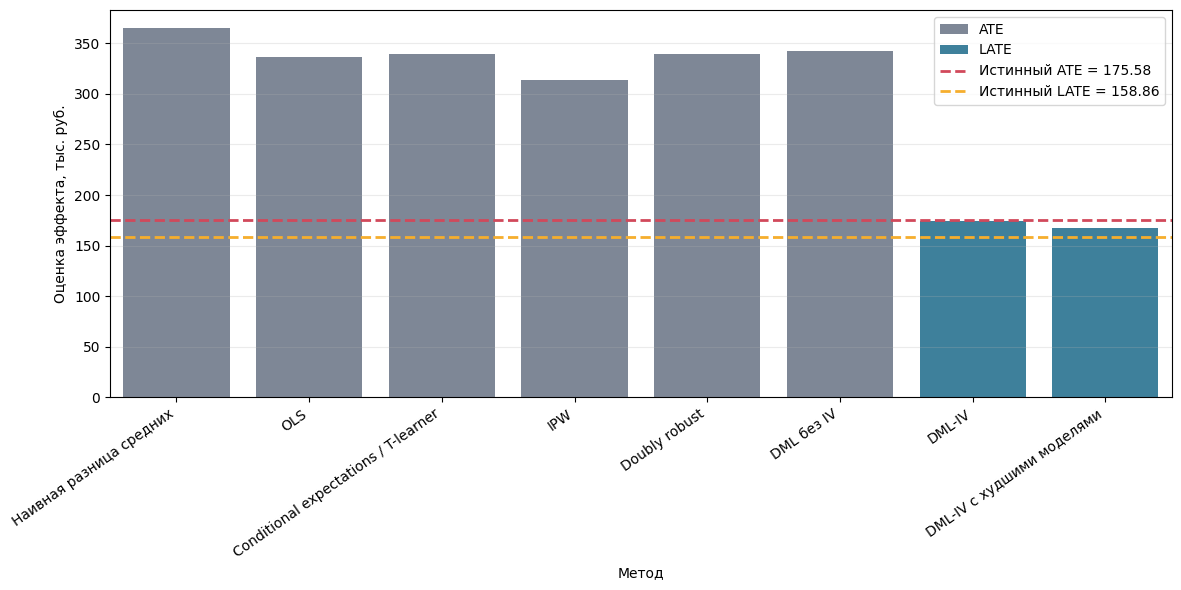

In [ ]:
plot_df = section5_summary_table[~section5_summary_table['Метод'].isin(['Истинный ATE', 'Истинный LATE'])]
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Метод', y='Оценка эффекта, тыс. руб.', hue='Эффект',
            dodge=False, palette={'ATE': '#7A869A', 'LATE': '#2E86AB'})
plt.axhline(true_ate, color='#D1495B', linestyle='--', linewidth=2, label=f'Истинный ATE = {true_ate:.2f}')
plt.axhline(true_late, color='#F6AE2D', linestyle='--', linewidth=2, label=f'Истинный LATE = {true_late:.2f}')
plt.xlabel('Метод'); plt.ylabel('Оценка эффекта, тыс. руб.')
plt.xticks(rotation=35, ha='right'); plt.grid(axis='y', alpha=0.25); plt.legend(); plt.tight_layout()
plt.savefig('section5_final_effect_comparison.png', dpi=150); plt.show()

### Задание 5.9. Дополнительный анализ: инструмент и устойчивость IPW

В качестве дополнительной проверки используем два небольших анализа. Во-первых, проверяем релевантность инструмента $PilotVoucher$: в first-stage регрессии он должен статистически значимо объяснять $MarketplaceAdoption$ после контроля за $BusinessAge$, $EmployeeCount$ и $OnlineSuitable$. Также сравниваем DML-IV с простой Wald-IV оценкой: если они близки, учет контролей и ML-nuisance-функций не меняет инструментальный вывод радикально; если различаются, это показывает роль контролей $W$.

Во-вторых, проверяем чувствительность IPW к экстремальным propensity scores. Очень малые или очень большие оценки $e(W)$ создают большие веса и могут делать IPW нестабильным. Обрезка $e(W)$ в диапазоне $[0.01, 0.99]$ защищает оценку от численных выбросов, но большое число обрезанных наблюдений было бы тревожным сигналом.


In [ ]:
# Задание 5.9. Дополнительные проверки: сила инструмента и sensitivity check для IPW.

# 1. First-stage регрессия D на Z и W: проверяем релевантность инструмента PilotVoucher.
design = np.column_stack([np.ones(len(W)), Z.to_numpy(float), W.to_numpy(float)])
names = ['const', 'PilotVoucher'] + CONTROLS
beta = np.linalg.lstsq(design, D.to_numpy(float), rcond=None)[0]
resid = D.to_numpy(float) - design @ beta
n_obs, k = design.shape
sigma2 = (resid @ resid) / (n_obs - k)
se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(design.T @ design)))
t_stat = beta / se
p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n_obs - k))
j = names.index('PilotVoucher')

first_stage_strength_table = pd.DataFrame({
    'Показатель': ['Коэффициент при PilotVoucher в first stage', 't-statistic', 'p-value',
                   'F-statistic для инструмента', 'E[D|Z=1] - E[D|Z=0] без контролей'],
    'Значение': [beta[j], t_stat[j], p_value[j], t_stat[j] ** 2,
                 D[Z == 1].mean() - D[Z == 0].mean()],
})
first_stage_strength_table['Значение'] = first_stage_strength_table['Значение'].round(4)
print('Проверка релевантности инструмента PilotVoucher\n')
display(first_stage_strength_table)

Проверка релевантности инструмента PilotVoucher



,Показатель,Значение
0,Коэффициент при PilotVoucher в first stage,0.2879
1,t-statistic,13.8325
2,p-value,0.0000
3,F-statistic для инструмента,191.3372
4,E[D|Z=1] - E[D|Z=0] без контролей,0.2754


In [ ]:

# 2. Sensitivity check для IPW: propensity score до и после clipping.
e_raw = pd.Series(make_classifier(best_clf_name, n_obs=len(W)).fit(W, D).predict_proba(W)[:, 1], index=W.index)
n_clip_low = int((e_raw < 0.01).sum())
n_clip_high = int((e_raw > 0.99).sum())
n_clipped = n_clip_low + n_clip_high

ipw_sensitivity_table = pd.DataFrame({
    'Показатель': ['Использованный классификатор', 'min e(W) до clipping', '1% квантиль e(W)',
                   '5% квантиль e(W)', 'mean e(W)', '95% квантиль e(W)', '99% квантиль e(W)',
                   'max e(W) до clipping', 'Обрезано снизу (<0.01)', 'Обрезано сверху (>0.99)',
                   'Всего обрезано', 'Доля обрезанных наблюдений'],
    'Значение': [best_clf_name, round(e_raw.min(), 4), round(e_raw.quantile(0.01), 4),
                 round(e_raw.quantile(0.05), 4), round(e_raw.mean(), 4), round(e_raw.quantile(0.95), 4),
                 round(e_raw.quantile(0.99), 4), round(e_raw.max(), 4), n_clip_low, n_clip_high,
                 n_clipped, round(n_clipped / len(e_raw), 4)],
})
print('Sensitivity check для propensity score в IPW\n')
display(ipw_sensitivity_table)

Sensitivity check для propensity score в IPW



,Показатель,Значение
0,Использованный классификатор,Градиентный бустинг
1,min e(W) до clipping,0.0919
2,1% квантиль e(W),0.1081
3,5% квантиль e(W),0.2214
4,mean e(W),0.4475
5,95% квантиль e(W),0.5973
6,99% квантиль e(W),0.6929
7,max e(W) до clipping,0.703
8,Обрезано снизу (<0.01),0
9,Обрезано сверху (>0.99),0


In [ ]:
# 3. Сравнение DML-IV и простой Wald-IV из задания 5.6.
iv_comparison_table = pd.DataFrame({
    'Метод': ['DML-IV', 'Wald-IV'],
    'Оценка LATE, тыс. руб.': [theta_dml_iv, wald_iv],
})
iv_comparison_table['Разница с Wald-IV, тыс. руб.'] = iv_comparison_table['Оценка LATE, тыс. руб.'] - wald_iv
iv_comparison_table['Истинный LATE, тыс. руб.'] = true_late
iv_comparison_table['Отклонение от истинного LATE, тыс. руб.'] = (
    iv_comparison_table['Оценка LATE, тыс. руб.'] - true_late)
for col in iv_comparison_table.select_dtypes('number').columns:
    iv_comparison_table[col] = iv_comparison_table[col].round(2)
print('Сравнение DML-IV и простой Wald-IV оценки\n')
display(iv_comparison_table)

Сравнение DML-IV и простой Wald-IV оценки



,Метод,"Оценка LATE, тыс. руб.","Разница с Wald-IV, тыс. руб.","Истинный LATE, тыс. руб.","Отклонение от истинного LATE, тыс. руб."
0,DML-IV,174.03,37.57,158.86,15.17
1,Wald-IV,136.47,0.00,158.86,-22.39
